# Predicting Bankruptcy using Altman Z-Scores and Alternative Financial Ratios

### Importing required libraries and loading the dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 1: Load the dataset
file_path = r'enter the source.csv'
df = pd.read_csv(file_path)
df['year'] = round(df['year'].astype(int), 0)

# Step 2: Recode the 'status_label' so that only the last observation in a panel is 'failed'
# Sort the dataset by company_name and year to ensure the panel is correctly ordered
df = df.sort_values(by=['company_name', 'year'])

# Identify the last observation for each panel
df['is_last'] = df.groupby('company_name')['year'].transform('max') == df['year']

# Recode 'status_label' based on whether it's the last observation
# df['status_label'] = df.apply(lambda row: 'failed' if row['is_last'] else 'alive', axis=1)

df['status_label_2'] = 'alive'
df.loc[(df['is_last']) & (df['status_label'] == 'failed'), 'status_label_2'] = 'failed'

# Step 3: Convert 'status_label' into a boolean called 'bankrupt'
df['bankrupt'] = df['status_label_2'].map({'alive': 0, 'failed': 1})

# Drop the 'is_last' and 'status_label' columns if no longer needed
df = df.drop(columns=['is_last', 'status_label', 'status_label_2'])

In [2]:
print(df[df['company_name'] == 'C_998'])

      company_name  year        X1        X2       X3       X4       X5  \
11886        C_998  1999  1468.808  1583.195   67.649  155.058  216.857   
11887        C_998  2000   574.528  1603.771   63.890   78.755  101.875   
11888        C_998  2001   799.499  1715.677   60.440  110.428  108.408   
11889        C_998  2002   762.905  1703.327   40.811 -115.120  149.848   
11890        C_998  2003   698.527  2208.338   44.504  -42.738   69.485   
11891        C_998  2004   799.923  1633.629   40.293   86.128   72.355   
11892        C_998  2005   993.099  1413.105   44.266  220.780   73.799   
11893        C_998  2006  2140.478  3305.921   61.000  425.696  307.915   
11894        C_998  2007  2757.500  4404.908   95.989  762.091  289.500   
11895        C_998  2008  2216.985  5393.694  126.133  590.782  440.096   
11896        C_998  2009  2357.921  4913.017  157.419  653.700  502.325   
11897        C_998  2010  1285.638  1744.622   76.452  442.358   67.528   
11898        C_998  2011 

In [3]:
bankruptcy_count_by_year = df[df['bankrupt'] == 1].groupby('year').size()
print(bankruptcy_count_by_year)

year
1999     3
2000     7
2001    10
2002    17
2003    29
2004    46
2005    40
2006    51
2007    59
2008    58
2009    23
2010    35
2011    25
2012    26
2013    28
2014    33
2015    33
2016    29
2017    21
2018    36
dtype: int64


### Caluclating LDA and QDA Accuracy

In [4]:
# Step 4: Prepare data for LDA and QDA
# Assuming variables X1-X18 are the feature columns
X = df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18']]
y = df['bankrupt']

# Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Perform LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)
y_pred_lda = lda.predict(X)

# Evaluate LDA performance
lda_accuracy = accuracy_score(y, y_pred_lda)
print(f'LDA Accuracy: {lda_accuracy:.2f}')

# Step 6: Perform QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X, y)
y_pred_qda = qda.predict(X)

# Evaluate QDA performance
qda_accuracy = accuracy_score(y, y_pred_qda)
print(f'QDA Accuracy: {qda_accuracy:.2f}')

LDA Accuracy: 0.99
QDA Accuracy: 0.15


/opt/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


### Calculating correlation matrix

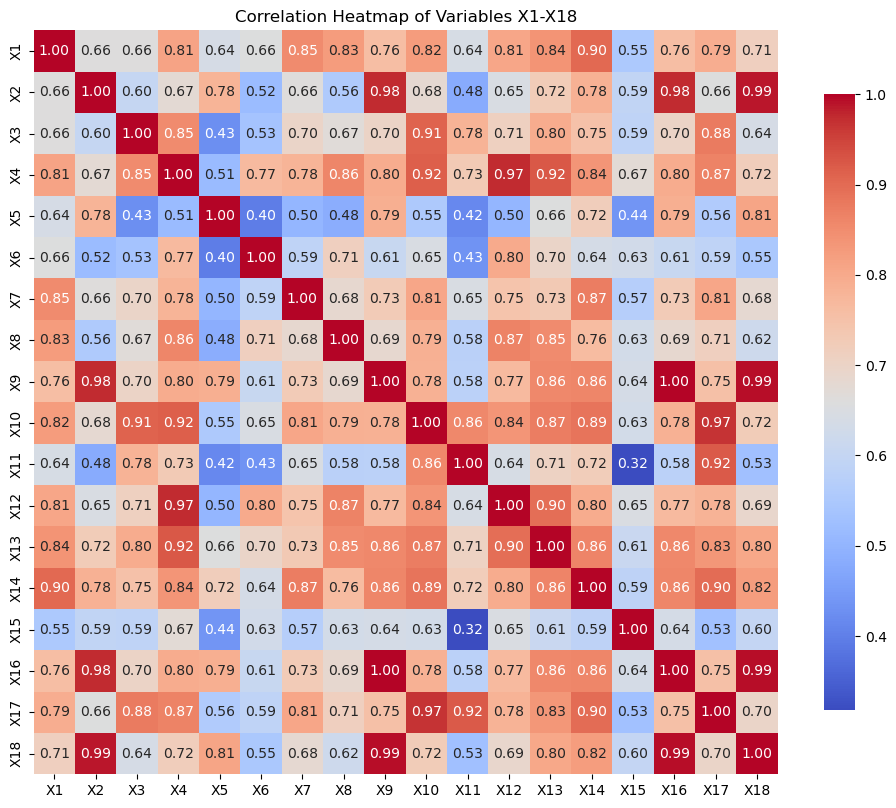

In [5]:
corr_matrix = df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 
                  'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18']].corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={'shrink': .8})

# Customize the plot
plt.title('Correlation Heatmap of Variables X1-X18')
plt.show()

### Calculating 5 ratios on which Altman Z-score rely on

In [6]:
# X1: Working Capital / Total Assets
# X2: Retained Earnings / Total Assets
# X3: EBIT / Total Assets
# X4: Market Value of Equity / Total Liabilities
# X5: Sales / Total Assets
df['X1_ratio'] = (df['X1'] - df['X14']) / df['X10']
df['X2_ratio'] = df['X15'] / df['X10']
df['X3_ratio'] = df['X12'] / df['X10']
df['X4_ratio'] = df['X8'] / df['X17']
df['X5_ratio'] = df['X9'] / df['X10']

### Calculating and printing Altman Z-Score

In [7]:
df['Z_score'] = (1.2 * df['X1_ratio'] + 1.4 * df['X2_ratio'] + 3.3 * df['X3_ratio'] + 0.6 * df['X4_ratio'] + df['X5_ratio'])
# Print Z-score
print("Z-score:")
print(df['Z_score']) 

Z-score:
0        3.196587
1        3.109968
2        2.226949
3        1.709901
4        2.240159
           ...   
11921    5.850142
11922    5.144117
11923    5.425894
11924    5.703962
11925    5.678522
Name: Z_score, Length: 78682, dtype: float64


### Evaluating Altman Z-score performace

Altman Z-Score Accuracy: 0.6403

Confusion Matrix:
[[49894 28179]
 [  121   488]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.64      0.78     78073
           1       0.02      0.80      0.03       609

    accuracy                           0.64     78682
   macro avg       0.51      0.72      0.41     78682
weighted avg       0.99      0.64      0.77     78682


Yearly Z-Score Performance:
year
1999    0.702713
2000    0.643513
2001    0.616091
2002    0.568050
2003    0.654969
2004    0.689742
2005    0.693698
2006    0.691376
2007    0.676228
2008    0.585688
2009    0.626503
2010    0.662345
2011    0.634785
2012    0.624103
2013    0.648680
2014    0.634418
2015    0.590638
2016    0.591037
2017    0.615461
2018    0.602644
dtype: float64


/var/folders/yb/ch9ckz8547sf_fl3g7f6r3ym0000gn/T/ipykernel_18124/2626693999.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_performance = df.groupby('year').apply(lambda x: accuracy_score(x['bankrupt'], x['z_score_predict']))


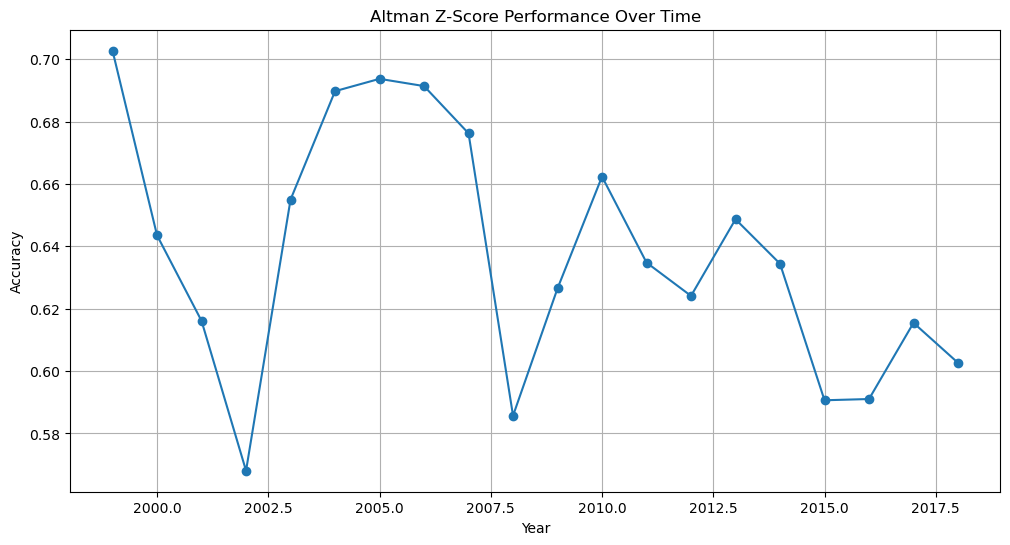

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# Create a binary classification based on Z-score
# Typically, Z-score < 1.8 indicates high probability of bankruptcy
df['z_score_predict'] = np.where(df['Z_score'] < 1.8, 1, 0)

# Calculate accuracy
z_score_accuracy = accuracy_score(df['bankrupt'], df['z_score_predict'])
print(f"Altman Z-Score Accuracy: {z_score_accuracy:.4f}")

# Print confusion matrix and classification report
print("\nConfusion Matrix:")
print(confusion_matrix(df['bankrupt'], df['z_score_predict']))
print("\nClassification Report:")
print(classification_report(df['bankrupt'], df['z_score_predict']))

# Analyze performance over time
yearly_performance = df.groupby('year').apply(lambda x: accuracy_score(x['bankrupt'], x['z_score_predict']))
print("\nYearly Z-Score Performance:")
print(yearly_performance)

# Visualize yearly performance
plt.figure(figsize=(12, 6))
yearly_performance.plot(kind='line', marker='o')
plt.title('Altman Z-Score Performance Over Time')
plt.xlabel('Year')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

### Evaluating Random Forest Performance

Random Forest Accuracy: 0.9925

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23426
           1       0.60      0.02      0.03       179

    accuracy                           0.99     23605
   macro avg       0.80      0.51      0.51     23605
weighted avg       0.99      0.99      0.99     23605



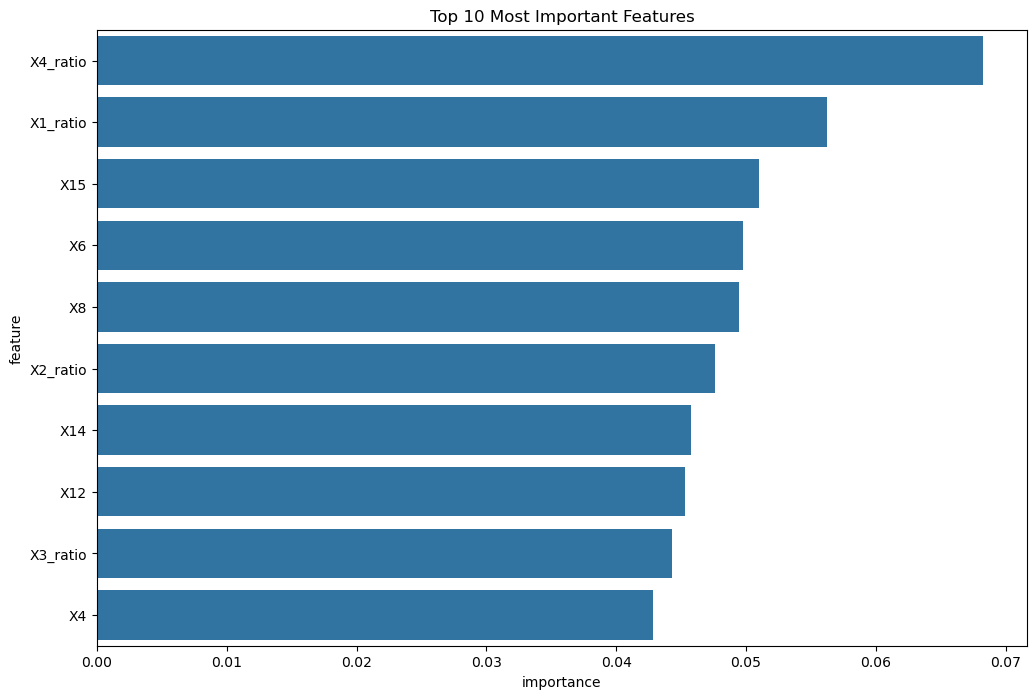

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Prepare features for the alternative model
features = ['X1_ratio', 'X2_ratio', 'X3_ratio', 'X4_ratio', 'X5_ratio', 
            'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 
            'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18']

X = df[features]
y = df['bankrupt']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Feature importance
feature_importance = pd.DataFrame({'feature': features, 'importance': rf_model.feature_importances_})
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 Most Important Features')
plt.show()

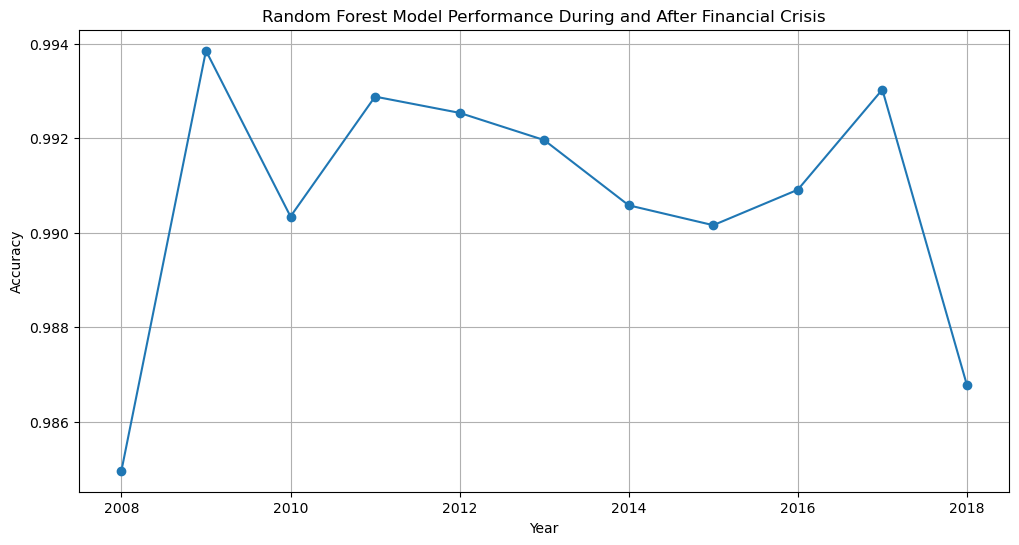

In [10]:
# Train the model on data up to 2007 and test on subsequent years
train_data = df[df['year'] <= 2007]
test_data = df[df['year'] > 2007]

X_train = train_data[features]
y_train = train_data['bankrupt']
X_test = test_data[features]
y_test = test_data['bankrupt']

rf_model_crisis = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_crisis.fit(X_train, y_train)

# Evaluate performance for each year after 2007
yearly_performance_rf = {}
for year in test_data['year'].unique():
    year_data = test_data[test_data['year'] == year]
    X_year = year_data[features]
    y_year = year_data['bankrupt']
    y_pred_year = rf_model_crisis.predict(X_year)
    yearly_performance_rf[year] = accuracy_score(y_year, y_pred_year)

# Visualize performance during and after the financial crisis
plt.figure(figsize=(12, 6))
plt.plot(yearly_performance_rf.keys(), yearly_performance_rf.values(), marker='o')
plt.title('Random Forest Model Performance During and After Financial Crisis')
plt.xlabel('Year')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()